<a href="https://colab.research.google.com/github/S-Keenan5/DATA-Projects/blob/main/DATA305_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Sean Keenan
#DATA305 Project
#ID: 300663823

import random
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, MaxPooling1D,
    GlobalMaxPooling1D, GlobalAveragePooling1D, Dense, Dropout,
    BatchNormalization, Concatenate)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

pep = pd.read_csv('peptides.csv')

In [ ]:
seeds = [1, 2, 3, 4, 5]
pep["length"] = pep["FASTA"].apply(len)

testsize = 0.10
valsize  = 0.10

#for encoding later
amino_fixed  = list("ACDEFGHIKLMNPQRSTVWY")
amino_number = len(amino_fixed)
amino_index  = {aa: i for i, aa in enumerate(amino_fixed)}

#so we can feed it into the network and determine length for every sequence input
pep["FASTA"].apply(len).max()
fixed_length = 50

In [ ]:
#one hot encoding to keep nominal order of amino acids
def one_hot_encode(sequences, fixed_length=fixed_length):
  n = len(sequences)
  x = np.zeros((n, fixed_length, amino_number), dtype=np.float32)

  for i, seq in enumerate(sequences):
    for j, aa in enumerate(seq[:fixed_length]):
      x[i, j, amino_index[aa]] = 1
  return x

# Encode FASTA.values because the function needs a basic array of strings
x_all = one_hot_encode(pep['FASTA'].values)
y_all = pep['Label'].values

In [ ]:
#amino acid composition — frequency of each of the 20 amino acids in the sequence
def compute_aac(sequences):
  records = []
  for seq in sequences:
    n = len(seq)
    freq = [seq.count(aa) / n for aa in amino_fixed]
    records.append(freq)
  return np.array(records, dtype=np.float32)

aac_all = compute_aac(pep['FASTA'].values)
print("AAC shape:", aac_all.shape)

AAC shape: (20114, 20)


In [ ]:
def build_model():
  #branch 1 — cnn on one-hot encoded sequences
  #learns local patterns by sliding filters along the sequence axis
  seq_inp = Input(shape=(fixed_length, amino_number), name='sequence')

  #block 1 128 filters
  x = Conv1D(128, 3, activation='relu', padding='same',
             kernel_initializer='he_normal')(seq_inp)
  x = BatchNormalization(name='bn1')(x)
  x = MaxPooling1D(pool_size=2)(x)
  x = Dropout(0.2)(x)

  #block 2 256 filters with kernel 5
  x = Conv1D(256, 5, activation='relu', padding='same',
             kernel_initializer='he_normal')(x)
  x = BatchNormalization(name='bn2')(x)
  x = MaxPooling1D(pool_size=2)(x)
  x = Dropout(0.2)(x)

  #block 3 no pooling as sequence is already short at 12 positions
  x = Conv1D(256, 3, activation='relu', padding='same',
             kernel_initializer='he_normal')(x)
  x = BatchNormalization(name='bn3')(x)
  x = Dropout(0.1)(x)

  #max captures strongest pattern signal, average captures overall sequence composition
  #merged both for more info
  x1 = GlobalMaxPooling1D()(x)
  x2 = GlobalAveragePooling1D()(x)
  cnn_out = Concatenate()([x1, x2])

  #branch 2 small dense network on amino acid composition frequencies
  aac_inp = Input(shape=(20,), name='aac')
  a = Dense(64, activation='relu', kernel_initializer='he_normal')(aac_inp)
  a = Dropout(0.1)(a)
  aac_out = Dense(32, activation='relu', kernel_initializer='he_normal')(a)

  #merged both branch
  merged = Concatenate()([cnn_out, aac_out])

  #dense head
  x = Dense(256, activation='relu', kernel_initializer='he_normal')(merged)
  x = Dropout(0.3)(x)
  x = Dense(128, activation='relu', kernel_initializer='he_normal')(x)
  x = Dropout(0.2)(x)

  output = Dense(1, activation='sigmoid')(x)

  model = Model(inputs=[seq_inp, aac_inp], outputs=output)
  model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy'])

  return model

build_model().summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence            │ (None, 50, 20)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 50, 128)   │      7,808 │ sequence[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 50, 128)   │        512 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 25, 128)   │          0 │ bn1[0][0]         │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 25, 128)   │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 25, 256)   │    164,096 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 25, 256)   │      1,024 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 12, 256)   │          0 │ bn2[0][0]         │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 12, 256)   │          0 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 12, 256)   │    196,864 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn3                 │ (None, 12, 256)   │      1,024 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aac (InputLayer)    │ (None, 20)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 12, 256)   │          0 │ bn3[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      1,344 │ aac[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ dropout_2[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ dropout_2[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 512)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 544)       │          0 │ concatenate[0][0… │
│ (Concatenate)       │                   │            │ dense_1[0][0]   

 Total params: 547,297 (2.09 MB)

 Trainable params: 546,017 (2.08 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [ ]:
results = []

for seed in seeds:
  random.seed(seed)
  np.random.seed(seed)
  tf.random.set_seed(seed)
  os.environ['PYTHONHASHSEED'] = str(seed)

  #created so that we dont split up the sequences and the labels like it would normally
  indices = np.arange(len(y_all))   # [0, 1, 2, ..., 20113]

  #Stratified split
  i_train, i_test = train_test_split(
      indices, test_size=testsize, stratify=y_all,
      random_state=seed)

  #validation split
  i_train_full, i_val = train_test_split(
      i_train, test_size=valsize, stratify=y_all[i_train],
      random_state=seed)

  x_tr,  y_tr  = x_all[i_train_full], y_all[i_train_full]
  x_val, y_val = x_all[i_val],        y_all[i_val]
  x_te,  y_te  = x_all[i_test],       y_all[i_test]

  #scale aac features — fit on training data only to avoid data leakage
  #StandardScaler transforms each feature to zero mean and unit variance
  scaler  = StandardScaler()
  aac_tr  = scaler.fit_transform(aac_all[i_train_full])
  aac_val = scaler.transform(aac_all[i_val])
  aac_te  = scaler.transform(aac_all[i_test])

  model = build_model()

  #patience 20 gives the model enough room to recover from plateaus
  early_stop = EarlyStopping(monitor='val_loss', patience=20,
                              verbose=1, restore_best_weights=True)

  #patience 5 fires before early stopping so the lr drops multiple times
  reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=5, verbose=1)

  #pass list of two inputs — sequence and aac
  history = model.fit([x_tr, aac_tr], y_tr,
                      validation_data=([x_val, aac_val], y_val),
                      epochs=200, batch_size=128, verbose=2,
                      callbacks=[early_stop, reduce_lr])

  #flatten converts to 1d array
  y_pred_prob = model.predict([x_te, aac_te]).flatten()

  roc_auc = roc_auc_score(y_te, y_pred_prob)
  print(f"Seed {seed}  |  AUC: {roc_auc:.4f}")

  pr_auc = average_precision_score(y_te, y_pred_prob)
  print(f"Seed {seed}  |  PR AUC: {pr_auc:.4f}")

  results.append({"seed": seed,
                  "AUC": roc_auc,
                  "PR AUC": pr_auc,
                  "history": history.history,
                  "y_te": y_te,
                  "y_pred_prob": y_pred_prob})

Epoch 1/200
128/128 - 21s - 168ms/step - accuracy: 0.8303 - loss: 0.4092 - val_accuracy: 0.5235 - val_loss: 0.7248 - learning_rate: 5.0000e-04
Epoch 2/200
128/128 - 1s - 8ms/step - accuracy: 0.8912 - loss: 0.2665 - val_accuracy: 0.7234 - val_loss: 0.5191 - learning_rate: 5.0000e-04
Epoch 3/200
128/128 - 1s - 8ms/step - accuracy: 0.9115 - loss: 0.2232 - val_accuracy: 0.8780 - val_loss: 0.2699 - learning_rate: 5.0000e-04
Epoch 4/200
128/128 - 1s - 9ms/step - accuracy: 0.9216 - loss: 0.1951 - val_accuracy: 0.9221 - val_loss: 0.1845 - learning_rate: 5.0000e-04
Epoch 5/200
128/128 - 1s - 8ms/step - accuracy: 0.9290 - loss: 0.1768 - val_accuracy: 0.9354 - val_loss: 0.1640 - learning_rate: 5.0000e-04
Epoch 6/200
128/128 - 1s - 6ms/step - accuracy: 0.9333 - loss: 0.1625 - val_accuracy: 0.9277 - val_loss: 0.1702 - learning_rate: 5.0000e-04
Epoch 7/200
128/128 - 1s - 6ms/step - accuracy: 0.9414 - loss: 0.1481 - val_accuracy: 0.9387 - val_loss: 0.1492 - learning_rate: 5.0000e-04
Epoch 8/200
128/1

In [ ]:
summary = pd.DataFrame([
    {"seed": r["seed"], "ROC AUC": r["AUC"], "PR AUC": r["PR AUC"]}
    for r in results])

print(summary)

roc_mean = summary['ROC AUC'].mean()
roc_std  = summary['ROC AUC'].std()
pr_mean  = summary['PR AUC'].mean()
pr_std   = summary['PR AUC'].std()

print(f"ROC AUC Mean: {roc_mean:.4f}   Std: {roc_std:.4f}")
print(f"PR AUC Mean: {pr_mean:.4f}   Std: {pr_std:.4f}")

   seed   ROC AUC    PR AUC
0     1  0.987440  0.988441
1     2  0.984228  0.983302
2     3  0.984014  0.985171
3     4  0.985834  0.985276
4     5  0.986039  0.987513
ROC AUC Mean: 0.9855   Std: 0.0014
PR AUC Mean: 0.9859   Std: 0.0020


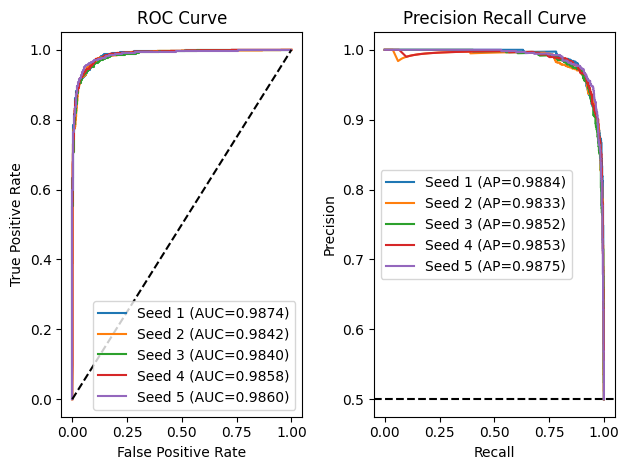

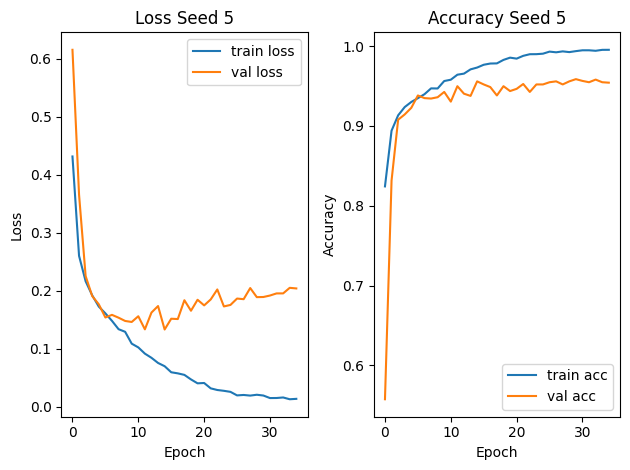

In [ ]:
#ROC and PR curves for all 5 seeds
fig, axes = plt.subplots(1, 2)

for r in results:
  fpr, tpr, _ = roc_curve(r['y_te'], r['y_pred_prob'])
  axes[0].plot(fpr, tpr, label=f"Seed {r['seed']} (AUC={r['AUC']:.4f})")

axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

for r in results:
  prec, rec, _ = precision_recall_curve(r['y_te'], r['y_pred_prob'])
  axes[1].plot(rec, prec, label=f"Seed {r['seed']} (AP={r['PR AUC']:.4f})")

axes[1].axhline(0.5, color='k', linestyle='--')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

#training history for the last seed
fig, axes = plt.subplots(1, 2)
last_hist = results[-1]['history']

axes[0].plot(last_hist['loss'], label='train loss')
axes[0].plot(last_hist['val_loss'], label='val loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Seed 5')
axes[0].legend()

axes[1].plot(last_hist['accuracy'], label='train acc')
axes[1].plot(last_hist['val_accuracy'], label='val acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Seed 5')
axes[1].legend()

plt.tight_layout()
plt.show()

Discussion-

I built dual input model combining a 1D CNN and an amino acid composition (aac) branch. I previously used a CNN with just one encoded input from the FASTA column. This consistently scored around 0.984 mean ROC AUC with seed 2 pulling the mean down almost every run. A key struggle I had was tuning the original CNN to get above the threshold of 0.985. This is why I added the AAC branch.


Architecture CNN branch

Sequences are one hot encoded where each row is a position and each column is one of the 20 standard amino acids. Block 1 uses 128 filters with kernel size 3 to detect short residue patterns. Block 2 uses 256 filters with kernel size 5 to detect medium 5-residue patterns. Block 3 uses 256 filters with no pooling to refine the representation as pooling was stopped here because the sequence was already compressed from 50 to 12. GlobalMaxPooling1D and GlobalAveragePooling1D are both computed and concatenated. Max pooling captures whether a strong sequence of residues exists anywhere in the sequence. Average pooling captures the overall activation level across all positions, reflecting global sequence composition. Combining both consistently improved PR AUC.

Architecture AAC branch

I created this simple branch after doing a small bit of research on bio computing on amino acid sequences and was primarily convinced as I knew the normal CNN wouldn't analyse the sequence as a whole but in peices through its kernel filter. The aac also made since in the context of the project. The aac computes the frequency of each of the 20 amino acids in the sequence. This gives more global information to the network regardless of the positions of the residues. Two small dense layers (64 and 32 neurons) learn which frequency patterns are associated with antimicrobial activity. Since the cnn branch has a small kernel size it may miss this information. StandardScaler was fitted on training data only and applied seperately to validation and test sets. Fitting on the full dataset would allow test set statistics to influence the feature scaling.

The aac is not an external dataset as is completely calculated from the existing FASTA column and just inputed seperately.

Training

Both inputs are passed as a list to model.fit and model.predict. Early stopping patienceof 20 gives the model room to recover from plateaus before stopping. Reduce lr on plateau with patience of 5 so that we can reduce learning rate before early stopping, halving the learning rate each
time.

Difficulties

The main difficulty was seed 2 consistently scoring below 0.985, dragging the mean below 0.985. I assumed this was because seed 2 had a harder test split that
contains more borderline sequences. The AAC branch helped solve this by providing the model with information about global sequence properties.

An earlier version without AAC scored ROC AUC mean 0.9841 and PR AUC mean 0.9843, both just below the 0.985 threshold. Adding the AAC branch while keeping the same CNN architecture pushed seed 2 up enough to clear both thresholds consistently.

What did I learn and future considerations.

Firstly, I learnt about the use of aac or Amino Acid Composition as a helpful feature engineering method in bio-computing. I also learnt the importance balance of how many convolutional blocks and how large dense layers should be to optimise computing performance.

Something I would like to try in the future is to use TF-IDF embedding in either an ensemble method or an rnn. I can see how the determining importance of residues in text form may be a usfeul method for determining antimicrobial activity especially as each residue is represented as a letter. This is a method I am less familiar with which is why i originally began with a CNN instead.

